In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd



sana = pd.read_csv("Indian_Employee_Data.csv")



In [3]:
sana.head()

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
0,EMP001,Rajesh Kumar,32.0,Male,Engineering,Senior Developer,850000.0,8.0,Bangalore,Karnataka,B.Tech,4.2,03/15/2016,12.0,45.0
1,EMP002,Priya Sharma,28.0,Female,Marketing,Marketing Manager,720000.0,5.0,Mumbai,Maharashtra,MBA,4.5,01/20/2019,8.0,32.0
2,EMP003,Amit Singh,35.0,Male,Finance,Financial Analyst,650000.0,10.0,Delhi,Delhi,CA,3.8,07/10/2014,15.0,28.0
3,EMP004,Sneha Patel,26.0,Female,NaN,HR Executive,480000.0,3.0,Ahmedabad,Gujarat,MBA,4.1,05/12/2021,6.0,20.0
4,EMP005,Vikram Reddy,40.0,Male,Engineering,Tech Lead,1200000.0,15.0,Hyderabad,Telangana,M.Tech,4.7,11/08/2009,25.0,55.0


In [4]:
sana.tail()

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
44,EMP045,Neha Kapoor,28.0,Female,IT,Data Analyst,NaN,4.0,Bangalore,Karnataka,M.Sc,3.8,04/12/2020,6.0,29.0
45,EMP046,Amit Sharma,27.0,Male,IT,Junior Developer,650000.0,4.0,Delhi,NaN,B.Tech,4.5,08/20/2020,5.0,25.0
46,EMP047,Riya Gupta,32.0,Female,HR,HR Specialist,NaN,8.0,Mumbai,Maharashtra,MBA,NaN,11/03/2016,inf,42.0
47,EMP048,Rohit Bansal,36.0,Male,Finance,Senior Analyst,980000.0,12.0,Mumbai,Maharashtra,CA,4.9,03/20/2012,19.0,51.0
48,EMP049,Sneha Tiwari,25.0,Female,Sales,Sales Representative,inf,2.0,Kolkata,West Bengal,B.Com,3.6,05/14/2022,3.0,16.0


In [5]:
sana.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         49 non-null     object 
 1   Name                49 non-null     object 
 2   Age                 47 non-null     float64
 3   Gender              49 non-null     object 
 4   Department          48 non-null     object 
 5   Position            48 non-null     object 
 6   Salary              44 non-null     float64
 7   Experience_Years    47 non-null     float64
 8   City                49 non-null     object 
 9   State               46 non-null     object 
 10  Education           49 non-null     object 
 11  Performance_Rating  45 non-null     float64
 12  Joining_Date        48 non-null     object 
 13  Projects_Completed  48 non-null     float64
 14  Overtime_Hours      48 non-null     float64
dtypes: float64(6), object(9)
memory usage: 5.9+ KB


In [6]:
sana.shape

(49, 15)

In [7]:
sana.dtypes

Employee_ID            object
Name                   object
Age                   float64
Gender                 object
Department             object
Position               object
Salary                float64
Experience_Years      float64
City                   object
State                  object
Education              object
Performance_Rating    float64
Joining_Date           object
Projects_Completed    float64
Overtime_Hours        float64
dtype: object

In [8]:
sana.size

735

In [4]:
sana.drop_duplicates()

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
0,EMP001,Rajesh Kumar,32.0,Male,Engineering,Senior Developer,850000.0,8.0,Bangalore,Karnataka,B.Tech,4.2,03/15/2016,12.0,45.0
1,EMP002,Priya Sharma,28.0,Female,Marketing,Marketing Manager,720000.0,5.0,Mumbai,Maharashtra,MBA,4.5,01/20/2019,8.0,32.0
2,EMP003,Amit Singh,35.0,Male,Finance,Financial Analyst,650000.0,10.0,Delhi,Delhi,CA,3.8,07/10/2014,15.0,28.0
3,EMP004,Sneha Patel,26.0,Female,NaN,HR Executive,480000.0,3.0,Ahmedabad,Gujarat,MBA,4.1,05/12/2021,6.0,20.0
4,EMP005,Vikram Reddy,40.0,Male,Engineering,Tech Lead,1200000.0,15.0,Hyderabad,Telangana,M.Tech,4.7,11/08/2009,25.0,55.0
5,EMP006,Kavya Nair,29.0,Female,Sales,Sales Executive,550000.0,4.0,Chennai,Tamil Nadu,B.Com,3.9,02/28/2020,inf,38.0
6,EMP007,Arjun Gupta,31.0,Male,Engineering,DevOps Engineer,NaN,7.0,Pune,Maharashtra,B.Tech,4.3,09/14/2017,11.0,42.0
7,EMP008,Meera Joshi,27.0,Female,Design,UI/UX Designer,620000.0,4.0,Bangalore,Karnataka,B.Des,4.4,08/03/2020,7.0,25.0
8,EMP009,Rohit Agarwal,33.0,Male,Finance,NaN,580000.0,9.0,Kolkata,West Bengal,M.Com,3.7,12/01/2015,13.0,30.0
9,EMP010,Anita Verma,38.0,Female,HR,HR Manager,950000.0,12.0,Gurgaon,Haryana,MBA,4.6,04/18/2012,18.0,48.0


In [5]:
sana.fillna(sana.mean(numeric_only=True), inplace=True)

In [6]:
# Replace infinity values with NaN
sana['Salary'] = sana['Salary'].replace([np.inf, -np.inf], np.nan)

# Fill NaN values with the mean of the Salary column
sana['Salary'].fillna(sana['Salary'].mean(), inplace=True)

In [7]:
sana['Joining_Date'] = pd.to_datetime(
    sana['Joining_Date'].fillna(sana['Joining_Date'].mode()[0])
)

In [8]:
sana.head()

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
0,EMP001,Rajesh Kumar,32.0,Male,Engineering,Senior Developer,850000.0,8.0,Bangalore,Karnataka,B.Tech,4.2,2016-03-15,12.0,45.0
1,EMP002,Priya Sharma,28.0,Female,Marketing,Marketing Manager,720000.0,5.0,Mumbai,Maharashtra,MBA,4.5,2019-01-20,8.0,32.0
2,EMP003,Amit Singh,35.0,Male,Finance,Financial Analyst,650000.0,10.0,Delhi,Delhi,CA,3.8,2014-07-10,15.0,28.0
3,EMP004,Sneha Patel,26.0,Female,NaN,HR Executive,480000.0,3.0,Ahmedabad,Gujarat,MBA,4.1,2021-05-12,6.0,20.0
4,EMP005,Vikram Reddy,40.0,Male,Engineering,Tech Lead,1200000.0,15.0,Hyderabad,Telangana,M.Tech,4.7,2009-11-08,25.0,55.0


In [9]:
sana['Age']=sana['Age'].astype(int)
sana['Salary']=sana['Salary'].astype(int)
sana['Performance_Rating']=sana['Performance_Rating'].round(1)


#columns_to_drop= ['Experience_Years','State','Education','Joining_Date']

In [10]:
sana.head()

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Experience_Years,City,State,Education,Performance_Rating,Joining_Date,Projects_Completed,Overtime_Hours
0,EMP001,Rajesh Kumar,32,Male,Engineering,Senior Developer,850000,8.0,Bangalore,Karnataka,B.Tech,4.2,2016-03-15,12.0,45.0
1,EMP002,Priya Sharma,28,Female,Marketing,Marketing Manager,720000,5.0,Mumbai,Maharashtra,MBA,4.5,2019-01-20,8.0,32.0
2,EMP003,Amit Singh,35,Male,Finance,Financial Analyst,650000,10.0,Delhi,Delhi,CA,3.8,2014-07-10,15.0,28.0
3,EMP004,Sneha Patel,26,Female,NaN,HR Executive,480000,3.0,Ahmedabad,Gujarat,MBA,4.1,2021-05-12,6.0,20.0
4,EMP005,Vikram Reddy,40,Male,Engineering,Tech Lead,1200000,15.0,Hyderabad,Telangana,M.Tech,4.7,2009-11-08,25.0,55.0


In [11]:
sana.to_csv('Cleaned_Indian_Employee_Data.csv',index=False)

In [12]:
sana_cleaned=pd.read_csv('Cleaned_Indian_Employee_Data.csv')

In [13]:
import os
print(os.getcwd())

C:\Users\Administrator\P.A & Modeling


In [14]:
print(sana_cleaned)

   Employee_ID            Name  Age  Gender   Department  \
0       EMP001    Rajesh Kumar   32    Male  Engineering   
1       EMP002    Priya Sharma   28  Female    Marketing   
2       EMP003      Amit Singh   35    Male      Finance   
3       EMP004     Sneha Patel   26  Female          NaN   
4       EMP005    Vikram Reddy   40    Male  Engineering   
5       EMP006      Kavya Nair   29  Female        Sales   
6       EMP007     Arjun Gupta   31    Male  Engineering   
7       EMP008     Meera Joshi   27  Female       Design   
8       EMP009   Rohit Agarwal   33    Male      Finance   
9       EMP010     Anita Verma   38  Female           HR   
10      EMP011     Suresh Iyer   42    Male  Engineering   
11      EMP012  Pooja Malhotra   32  Female    Marketing   
12      EMP013    Karan Chopra   30    Male        Sales   
13      EMP014       Divya Rao   34  Female  Engineering   
14      EMP015    Manoj Tiwari   36    Male   Operations   
15      EMP016     Ritu Bansal   28  Fem

In [15]:
import pandas as pd
data={"Salary":[1000,2000,3000, 4000, 5000,6000,7000,8000,9000,10000],
     "Experince":[1,2,3,4,5,6,7,8,9,10]}

In [16]:
ps=pd.DataFrame(data)

print(ps.corr())

           Salary  Experince
Salary        1.0        1.0
Experince     1.0        1.0


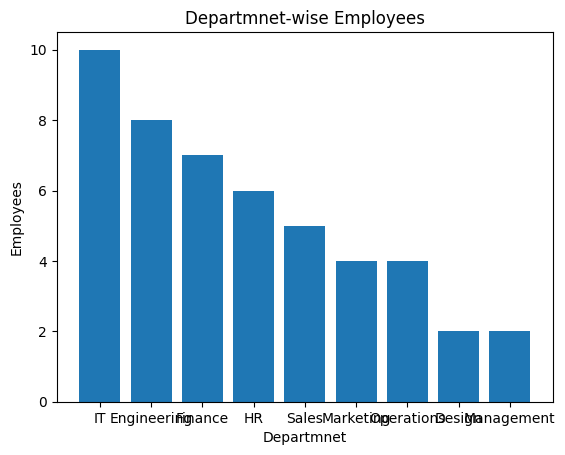

In [17]:
dept = sana['Department'].value_counts()
plt.bar(dept.index,dept.values)


plt.title("Departmnet-wise Employees")

plt.xlabel("Departmnet")
plt.ylabel("Employees")
plt.show()

In [18]:
dept = sana['Gender'].value_counts()
plt.pie(gender.values,labels=gender.index,autopct='%1.1f%')


plt.title("Gender Distribution")


plt.show()

NameError: name 'gender' is not defined

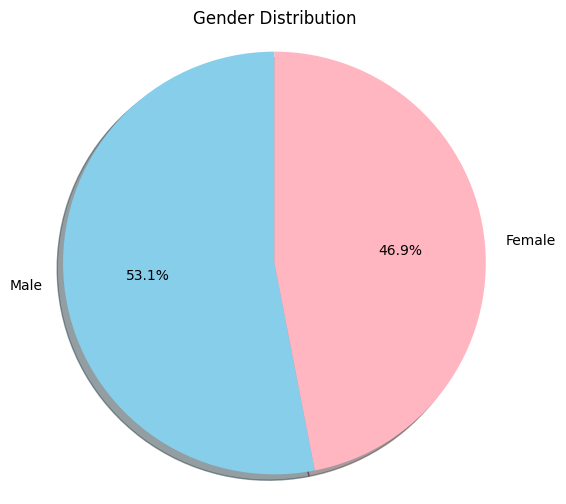

In [19]:
import matplotlib.pyplot as plt

# Count the number of employees in each gender
gender = sana['Gender'].value_counts()

# Create pie chart
plt.figure(figsize=(6, 6))

plt.pie(
    gender.values,
    labels=gender.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=['skyblue', 'lightpink']
)

plt.title("Gender Distribution")
plt.axis('equal')  # Makes the pie chart a perfect circle

plt.show()